# Fase 5 — Robustez estadística / multiseed (`cuda_seed1337`)

## Finalidad

Según el plan (`PLAN_ACCION_AJUSTES_MODELOS.md` §3 Fase 5), repetir el **mismo** procedimiento cascada ya integrado (Fase 3 + Fase 4 en el notebook vivo) con **otra semilla** para comprobar si las métricas de test se **replican** en dirección y magnitud.

## Qué cambia en este notebook

| Aspecto | Valor |
|---------|--------|
| `SEED` | **1337** |
| `OUTPUT_DIR` (relativo a `analysis_outputs_v3`) | `training_runs_cascade_v3_fase5_multiseed_cuda_s1337` |
| Checkpoints en `MODEL_DIR` | sufijo **`s1337`** en los `.pt` |

El resto (épocas, resolución, augment ROI train, LR multiclase + cosine, `cudnn` determinista) coincide con `train_spine_cascade_binary_to_thoracolumbar_v3.ipynb`.

## Variante: **CUDA — semilla 1337**

Misma lógica que el notebook vivo (Fase 3 + Fase 4). Único cambio experimental: `SEED = 1337` y rutas de salida propias.

---

## Colab — raíz por defecto (`_cuda`)

Si el repo llega a Drive como **Other computers / Mi portátil / ScoliosisSegmentation**, la celda de configuración prueba **antes** que `MyDrive` la ruta:

`/content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation`

Si tu carpeta tiene otro nombre, usa `MAIA_PROJECT_ROOT` o `%cd` a la raíz del clon.

---



### [Colab — `_cuda`] Comprobar CUDA

En **Google Colab** elige runtime **T4 GPU** (o superior). En VS Code / Jupyter local esta celda solo comprueba si `torch.cuda` ve una GPU.



In [1]:
import torch

if torch.cuda.is_available():
    print("CUDA is available! GPU device:", torch.cuda.get_device_name(0))
    print("Number of CUDA devices:", torch.cuda.device_count())
else:
    print("CUDA is not available. Please ensure you have selected a GPU runtime.")


CUDA is available! GPU device: Tesla T4
Number of CUDA devices: 1


### [Colab — `_cuda`] Montar Google Drive

Solo aplica en **Colab**. Fuera de Colab se captura `ImportError` y se imprime un mensaje; no hace falta montar Drive si el repo ya esta en disco.



In [2]:
try:
    from google.colab import drive

    drive.mount('/content/drive')
except ImportError:
    print(
        "[Info] No hay entorno Colab (google.colab): se omite drive.mount. "
        "En VS Code / Jupyter local el repo ya esta en disco; en Colab ejecuta esta celda para montar Drive."
    )


Mounted at /content/drive


# Entrenamiento en cascada: binary spine -> thoracolumbar

Este notebook construye una **segunda version del pipeline de entrenamiento** con una idea mas cercana al objetivo real del proyecto:

**identificar vertebras**, no solo segmentar la columna completa.

Para eso usamos una cascada de dos etapas:

1. **Modelo 1 - Binary spine**: aprende a separar columna vs fondo.
2. **Modelo 2 - Thoracolumbar multiclass**: recibe una imagen ya enfocada en la region de columna y aprende a distinguir `T1..T12` y `L1..L5`.

La intuicion es sencilla:

- si la red multiclase ve toda la radiografia, desperdicia capacidad en fondo y anatomia irrelevante
- si primero aislamos la columna, la segunda red puede concentrarse en diferencias finas entre vertebras vecinas
- esto nos acerca mas a un pipeline util para identificacion anatomica

## Metodologia de este notebook

La metodologia completa queda asi:

1. Cargar el `manifest` thoracolumbar ya depurado.
2. Hacer un split por paciente/grupo para evitar fuga de informacion:
   - `64% train`
   - `16% val`
   - `20% test`
3. Entrenar una U-Net pequena para **segmentacion binaria**.
4. Usar ese modelo binario para estimar una **ROI espinal** sobre `val` y `test`.
5. Entrenar una segunda U-Net multiclase solo sobre el recorte de columna.
6. Medir el rendimiento final con metricas globales y por vertebra.

Decisiones importantes:

- El target anatomico sigue siendo solo `thoracic + lumbar`.
- Las cervicales excluidas no se convierten en fondo; se tratan como `ignore`.
- En entrenamiento multiclase usamos ROI basada en mascara binaria real para dar estabilidad.
- En validacion y prueba usamos ROI predicha por la red binaria, para aproximarnos mejor al escenario real.

## Arquitectura del modelo

En ambas etapas usamos la misma familia de modelo: una **U-Net pequena**.

Estructura general:

- **Encoder**: extrae caracteristicas cada vez mas abstractas mientras reduce resolucion.
- **Bottleneck**: concentra el contexto global de la imagen.
- **Decoder**: recupera resolucion espacial.
- **Skip connections**: combinan detalle fino del encoder con contexto del decoder.

Canales base:

- `32 -> 64 -> 128 -> 256 -> 512`

Diferencia entre las dos etapas:

- en binaria, la capa final produce `1` canal
- en multiclase, la capa final produce `18` canales:
  - `background`
  - `T1..T12`
  - `L1..L5`

Por que esta arquitectura tiene sentido aqui:

- la U-Net funciona bien en segmentacion medica
- preserva detalle espacial importante
- es lo bastante liviana para iterar rapido
- nos sirve como baseline antes de pasar a arquitecturas mas pesadas

## Antes de ejecutar

Asegurate de tener:

- `Scoliosis_Dataset_V3/Scoliosis_Dataset/indice_dataset.csv`
- `Scoliosis_Dataset_V3/Scoliosis_Dataset/diccionario_etiquetas_T1_T12_L1_L5.json`
- `analysis_outputs_v3/training_manifest_thoracolumbar_v3.csv`

Si faltan librerias:

```python
%pip install -r requirements-notebook.txt
%pip install torch torchvision torchaudio
```

Salidas esperadas:

- pesos en `models/`
- metricas y particiones en `analysis_outputs_v3/training_runs_cascade_v3_fase5_multiseed_cuda_s1337/`

In [3]:
from __future__ import annotations

import json
import os
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Reproducibilidad en GPU (opcional; algo más lento). Útil para acercar runs entre máquinas.
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def _resolve_maia_project_root(marker: Path) -> Path:
    """Raiz del repo (carpeta que contiene marker). Local, subcarpetas, Colab+Drive."""
    env = os.environ.get('MAIA_PROJECT_ROOT', '').strip()
    if env:
        p = Path(env).expanduser().resolve()
        if (p / marker).exists():
            return p
    cwd = Path.cwd().resolve()
    for cand in [cwd, *cwd.parents]:
        if (cand / marker).exists():
            return cand
    # [Colab _cuda] Drive sincronizado: Other computers / Mi portatil / ScoliosisSegmentation
    _colab_cuda_root = Path(r'/content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation')
    if _colab_cuda_root.is_dir() and (_colab_cuda_root / marker).exists():
        return _colab_cuda_root.resolve()
    drive_nb = Path('/content/drive/MyDrive/Colab Notebooks')
    if drive_nb.is_dir():
        direct = drive_nb / 'MAIA-PROYECTO'
        if (direct / marker).exists():
            return direct.resolve()
        for child in drive_nb.iterdir():
            try:
                if child.is_dir() and (child / marker).exists():
                    return child.resolve()
            except OSError:
                continue
    drive_maia = Path('/content/drive/MyDrive/MAIA-PROYECTO')
    if (drive_maia / marker).exists():
        return drive_maia.resolve()
    raise FileNotFoundError(
        f"No se encontro {marker.as_posix()}. Opciones: (1) %cd a la raiz del repo; "
        f"(2) os.environ['MAIA_PROJECT_ROOT'] = r'.../MAIA-PROYECTO'. cwd={cwd}"
    )


ROOT = _resolve_maia_project_root(Path('data') / 'Scoliosis_Dataset')

DATASET_DIR = ROOT / 'data' / 'Scoliosis_Dataset'
DATASET_INDEX_PATH = DATASET_DIR / 'indice_dataset.csv'
LABELS_DICT_PATH = DATASET_DIR / 'diccionario_etiquetas_T1_T12_L1_L5.json'
MANIFEST_PATH = ROOT / 'outputs' / 'analysis_outputs_v3' / 'training_manifest_thoracolumbar_v3.csv'
OUTPUT_DIR = ROOT / 'outputs' / 'analysis_outputs_v3' / 'training_runs_cascade_v3_fase5_multiseed_cuda_s1337'
MODEL_DIR = ROOT / 'models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'

IMG_SIZE_BINARY = (512, 256)
IMG_SIZE_MULTICLASS = (512, 256)
BATCH_SIZE = 4
NUM_WORKERS = 0
LR = 1e-3
WEIGHT_DECAY = 1e-4
BINARY_EPOCHS = 14
MULTICLASS_EPOCHS = 24
TEST_RATIO = 0.20
VAL_RATIO_WITHIN_DEV = 0.20
IGNORE_INDEX = 255
MULTICLASS_SUBSET = 'core'   # cambiar a 'partial' en una iteracion posterior
BINARY_THRESHOLD = 0.50
ROI_PAD_X = 18
ROI_PAD_Y = 30
ROI_JITTER_X = 10
ROI_JITTER_Y = 14
MIN_FOREGROUND_PIXELS = 24

TARGET_LABELS = [f'T{i}' for i in range(1, 13)] + [f'L{i}' for i in range(1, 6)]
EXCLUDED_LABELS = ['C7', 'C6', 'C5', 'C4', 'C3']

dataset_index_df = pd.read_csv(DATASET_INDEX_PATH)
# Normalizar esquema del indice V3 para compatibilidad con el pipeline.
dataset_index_df = dataset_index_df.rename(columns={
    'grupo': 'split',
    'imagen': 'image',
    'id_paciente': 'patient_id',
    'ruta_radiografia': 'radiograph_path',
    'ruta_mascara_binaria': 'label_binary_path',
    'ruta_mascara_multiclase_id_png': 'multiclass_path',
})
dataset_index_df['mask_path'] = dataset_index_df['multiclass_path']
manifest_df = pd.read_csv(MANIFEST_PATH)
with open(LABELS_DICT_PATH, 'r', encoding='utf-8') as f:
    labels_dict = json.load(f)

multiclass_key = 'multiclass_id_png' if 'multiclass_id_png' in labels_dict else 'mascara_multiclase_id_png'
multiclass_map = {int(k): v for k, v in labels_dict[multiclass_key].items()}
label_to_id = {label: class_id for class_id, label in multiclass_map.items()}
target_id_to_train_id = {label_to_id[label]: idx + 1 for idx, label in enumerate(TARGET_LABELS)}
class_names = ['background'] + TARGET_LABELS
num_classes = len(class_names)

join_cols = ['split', 'image', 'patient_id', 'radiograph_path']
dataset_subset = dataset_index_df[join_cols + ['label_binary_path', 'multiclass_path']].copy()
train_table = manifest_df.merge(dataset_subset, on=join_cols, how='left', suffixes=('', '_idx'))

train_table['multiclass_path'] = train_table['mask_path'].fillna(train_table['multiclass_path'])
train_table['radiograph_path_abs'] = train_table['radiograph_path'].apply(lambda rel: str((DATASET_DIR / rel).resolve()))
train_table['binary_mask_path_abs'] = train_table['label_binary_path'].apply(lambda rel: str((DATASET_DIR / rel).resolve()))
train_table['multiclass_mask_path_abs'] = train_table['multiclass_path'].apply(lambda rel: str((DATASET_DIR / rel).resolve()))

flag_cols = [
    'usable_for_binary_spine',
    'usable_for_thoracolumbar_core',
    'usable_for_thoracolumbar_partial',
    'needs_annotation_review',
    'usable_for_cobb_regression',
]
for col in flag_cols:
    if col in train_table.columns:
        train_table[col] = train_table[col].map(
            lambda x: x if isinstance(x, bool) else str(x).strip().lower() == 'true'
        )

print('FASE 5 multiseed s1337 (cuda) — OUTPUT_DIR:', OUTPUT_DIR)
print('ROOT:', ROOT)
print('DEVICE:', DEVICE)
print('Muestras totales del manifest:', len(train_table))
print('Subset binario utilizable:', int(train_table['usable_for_binary_spine'].sum()))
print('Subset thoracolumbar core:', int(train_table['usable_for_thoracolumbar_core'].sum()))
print('Subset thoracolumbar partial:', int(train_table['usable_for_thoracolumbar_partial'].sum()))
print('Casos sugeridos para revision manual:', int(train_table['needs_annotation_review'].sum()))

display(
    train_table[
        [
            'unique_sample_id', 'split', 'image', 'group_id_for_split',
            'num_visible_target_vertebrae', 'visible_target_span_signature',
            'excluded_cervical_count', 'total_internal_missing_count',
            'unexpected_label_count', 'usable_for_binary_spine',
            'usable_for_thoracolumbar_core', 'usable_for_thoracolumbar_partial',
            'needs_annotation_review'
        ]
    ].head()
)


FASE 5 multiseed s1337 (cuda) — OUTPUT_DIR: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation/outputs/analysis_outputs_v3/training_runs_cascade_v3_fase5_multiseed_cuda_s1337
ROOT: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation
DEVICE: cuda
Muestras totales del manifest: 249
Subset binario utilizable: 249
Subset thoracolumbar core: 198
Subset thoracolumbar partial: 228
Casos sugeridos para revision manual: 8


,unique_sample_id,split,image,group_id_for_split,num_visible_target_vertebrae,visible_target_span_signature,excluded_cervical_count,total_internal_missing_count,unexpected_label_count,usable_for_binary_spine,usable_for_thoracolumbar_core,usable_for_thoracolumbar_partial,needs_annotation_review
0,Normal__N_1.jpg,Normal,N_1.jpg,Normal_1,17,T1-L5,0,0,0,True,True,True,False
1,Normal__N_2.jpg,Normal,N_2.jpg,Normal_2,17,T1-L5,0,0,0,True,True,True,False
2,Normal__N_3.jpg,Normal,N_3.jpg,Normal_3,17,T1-L5,0,0,0,True,True,True,False
3,Normal__N_4.jpg,Normal,N_4.jpg,Normal_4,17,T1-L5,0,0,0,True,True,True,False
4,Normal__N_5.jpg,Normal,N_5.jpg,Normal_5,17,T1-L5,0,0,0,True,True,True,False


## Seccion 1. Particion de datos

Aqui hacemos el split del dataset con dos objetivos:

1. reservar un `test` real que no se use para decisiones del modelo
2. tener un `validation` intermedio para elegir el mejor checkpoint

Es importante que el split sea por `group_id_for_split`, porque asi evitamos que imagenes relacionadas queden repartidas entre entrenamiento y evaluacion.

In [4]:
def make_group_train_val_test_split(
    df_in: pd.DataFrame,
    test_ratio: float = 0.20,
    val_ratio_within_dev: float = 0.20,
    seed: int = 42,
) -> pd.DataFrame:
    work = df_in.reset_index(drop=True).copy()

    holdout_splitter = GroupShuffleSplit(n_splits=1, test_size=test_ratio, random_state=seed)
    dev_idx, test_idx = next(holdout_splitter.split(work, groups=work['group_id_for_split']))
    dev_df = work.iloc[dev_idx].copy()
    test_df = work.iloc[test_idx].copy()

    val_splitter = GroupShuffleSplit(n_splits=1, test_size=val_ratio_within_dev, random_state=seed)
    train_idx, val_idx = next(val_splitter.split(dev_df, groups=dev_df['group_id_for_split']))
    train_df = dev_df.iloc[train_idx].copy()
    val_df = dev_df.iloc[val_idx].copy()

    train_df['partition'] = 'train'
    val_df['partition'] = 'val'
    test_df['partition'] = 'test'
    return pd.concat([train_df, val_df, test_df], ignore_index=True)


binary_df = train_table.loc[train_table['usable_for_binary_spine']].copy()
multiclass_flag = 'usable_for_thoracolumbar_core' if MULTICLASS_SUBSET == 'core' else 'usable_for_thoracolumbar_partial'
multiclass_df = train_table.loc[train_table[multiclass_flag] & ~train_table['needs_annotation_review']].copy()

binary_splits_df = make_group_train_val_test_split(
    binary_df,
    test_ratio=TEST_RATIO,
    val_ratio_within_dev=VAL_RATIO_WITHIN_DEV,
    seed=SEED,
)
multiclass_splits_df = make_group_train_val_test_split(
    multiclass_df,
    test_ratio=TEST_RATIO,
    val_ratio_within_dev=VAL_RATIO_WITHIN_DEV,
    seed=SEED,
)

binary_split_path = OUTPUT_DIR / 'binary_spine_split_train_val_test.csv'
multiclass_split_path = OUTPUT_DIR / f'thoracolumbar_{MULTICLASS_SUBSET}_split_train_val_test.csv'
binary_splits_df.to_csv(binary_split_path, index=False)
multiclass_splits_df.to_csv(multiclass_split_path, index=False)

print('Split binario guardado en:', binary_split_path)
print('Split multiclase guardado en:', multiclass_split_path)

print('\nDistribucion binaria:')
display(binary_splits_df['partition'].value_counts().rename_axis('partition').reset_index(name='images'))
display(binary_splits_df.groupby(['partition', 'split']).size().rename('images').reset_index())

print('\nDistribucion multiclase:')
display(multiclass_splits_df['partition'].value_counts().rename_axis('partition').reset_index(name='images'))
display(multiclass_splits_df.groupby(['partition', 'split']).size().rename('images').reset_index())

for df_check in [binary_splits_df, multiclass_splits_df]:
    train_groups = set(df_check.loc[df_check['partition'] == 'train', 'group_id_for_split'])
    val_groups = set(df_check.loc[df_check['partition'] == 'val', 'group_id_for_split'])
    test_groups = set(df_check.loc[df_check['partition'] == 'test', 'group_id_for_split'])
    assert train_groups.isdisjoint(val_groups)
    assert train_groups.isdisjoint(test_groups)
    assert val_groups.isdisjoint(test_groups)

Split binario guardado en: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation/outputs/analysis_outputs_v3/training_runs_cascade_v3_fase5_multiseed_cuda_s1337/binary_spine_split_train_val_test.csv
Split multiclase guardado en: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation/outputs/analysis_outputs_v3/training_runs_cascade_v3_fase5_multiseed_cuda_s1337/thoracolumbar_core_split_train_val_test.csv

Distribucion binaria:


,partition,images
0,train,159
1,test,50
2,val,40


,partition,split,images
0,test,Normal,16
1,test,Scoliosis,34
2,train,Normal,41
3,train,Scoliosis,118
4,val,Normal,14
5,val,Scoliosis,26



Distribucion multiclase:


,partition,images
0,train,126
1,test,40
2,val,32


,partition,split,images
0,test,Normal,16
1,test,Scoliosis,24
2,train,Normal,34
3,train,Scoliosis,92
4,val,Normal,14
5,val,Scoliosis,18


## Seccion 2. Preparacion de imagenes, mascaras y ROI

Esta es una de las partes mas importantes del notebook.

Que hacemos aqui:

- leemos radiografia y mascaras
- convertimos la mascara binaria a `0/1`
- convertimos la mascara multiclase original al nuevo espacio de clases
- calculamos una **ROI** que encierre la columna
- recortamos la imagen a esa ROI antes de pasarla al modelo multiclase

Idea clave:

- en `train` multiclase usamos ROI basada en la mascara binaria real para dar estabilidad
- en `val/test` multiclase usamos ROI predicha por el modelo binario

Asi la segunda red aprende con una region anatomica coherente, pero al mismo tiempo la evaluamos en un flujo mas parecido al uso real.

### [FASE 5 — MULTISEED] Semilla **1337**

- Mismo código que el cascada V3 vivo salvo `SEED` y rutas de esta variante.
- Tras ejecutar las tres variantes, comparar `macro_dice_fg` / `macro_iou_fg` en test y decidir según el plan (replicación vs «prometedor, no consolidado»).


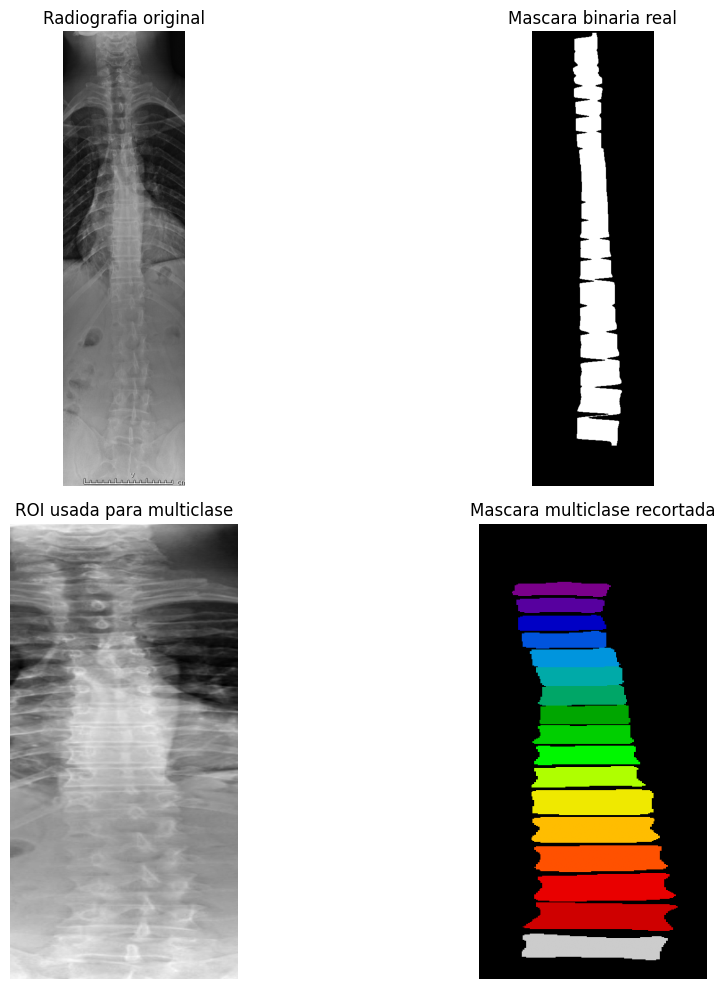

In [5]:
def read_gray(path: str) -> np.ndarray:
    return np.array(Image.open(path).convert('L'))


def resize_image(arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    return np.array(Image.fromarray(arr).resize((size[1], size[0]), resample=Image.BILINEAR))


def resize_mask(arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    return np.array(Image.fromarray(arr.astype(np.uint8)).resize((size[1], size[0]), resample=Image.NEAREST))


def build_binary_mask(path: str, size: tuple[int, int] | None = None) -> np.ndarray:
    mask = read_gray(path)
    mask = (mask >= 127).astype(np.uint8)
    if size is not None:
        mask = resize_mask(mask, size)
    return mask


def build_multiclass_mask(path: str, size: tuple[int, int] | None = None) -> np.ndarray:
    raw = np.array(Image.open(path), dtype=np.int32)
    out = np.zeros_like(raw, dtype=np.uint8)
    out[raw != 0] = IGNORE_INDEX
    for old_id, new_id in target_id_to_train_id.items():
        out[raw == old_id] = new_id
    if size is not None:
        out = resize_mask(out, size)
    return out


def bbox_from_mask(mask: np.ndarray, min_foreground_pixels: int = 24) -> tuple[int, int, int, int] | None:
    ys, xs = np.where(mask > 0)
    if len(xs) < min_foreground_pixels:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()) + 1, int(ys.max()) + 1


def clamp_bbox(bbox: tuple[int, int, int, int], image_shape: tuple[int, int]) -> tuple[int, int, int, int]:
    h, w = image_shape
    x0, y0, x1, y1 = bbox
    x0 = max(0, min(x0, w - 1))
    y0 = max(0, min(y0, h - 1))
    x1 = max(x0 + 1, min(x1, w))
    y1 = max(y0 + 1, min(y1, h))
    return x0, y0, x1, y1


def expand_bbox(
    bbox: tuple[int, int, int, int],
    image_shape: tuple[int, int],
    pad_x: int = 18,
    pad_y: int = 30,
) -> tuple[int, int, int, int]:
    x0, y0, x1, y1 = bbox
    return clamp_bbox((x0 - pad_x, y0 - pad_y, x1 + pad_x, y1 + pad_y), image_shape)


def jitter_bbox(
    bbox: tuple[int, int, int, int],
    image_shape: tuple[int, int],
    max_jitter_x: int = 10,
    max_jitter_y: int = 14,
) -> tuple[int, int, int, int]:
    x0, y0, x1, y1 = bbox
    dx0 = np.random.randint(-max_jitter_x, max_jitter_x + 1)
    dx1 = np.random.randint(-max_jitter_x, max_jitter_x + 1)
    dy0 = np.random.randint(-max_jitter_y, max_jitter_y + 1)
    dy1 = np.random.randint(-max_jitter_y, max_jitter_y + 1)
    return clamp_bbox((x0 + dx0, y0 + dy0, x1 + dx1, y1 + dy1), image_shape)


def crop_array(arr: np.ndarray, bbox: tuple[int, int, int, int]) -> np.ndarray:
    x0, y0, x1, y1 = bbox
    return arr[y0:y1, x0:x1]


def scale_bbox(
    bbox: tuple[int, int, int, int],
    src_shape: tuple[int, int],
    dst_shape: tuple[int, int],
) -> tuple[int, int, int, int]:
    src_h, src_w = src_shape
    dst_h, dst_w = dst_shape
    x0, y0, x1, y1 = bbox
    sx = dst_w / src_w
    sy = dst_h / src_h
    scaled = (
        int(round(x0 * sx)),
        int(round(y0 * sy)),
        int(round(x1 * sx)),
        int(round(y1 * sy)),
    )
    return clamp_bbox(scaled, dst_shape)


def full_image_bbox(image_shape: tuple[int, int]) -> tuple[int, int, int, int]:
    h, w = image_shape
    return 0, 0, w, h


def build_roi_record_from_binary_mask(
    binary_mask: np.ndarray,
    image_shape: tuple[int, int],
    roi_source: str,
    pad_x: int = ROI_PAD_X,
    pad_y: int = ROI_PAD_Y,
) -> dict:
    bbox = bbox_from_mask(binary_mask, min_foreground_pixels=MIN_FOREGROUND_PIXELS)
    if bbox is None:
        bbox = full_image_bbox(image_shape)
        roi_source = f'{roi_source}_fallback_full_image'
    else:
        bbox = expand_bbox(bbox, image_shape=image_shape, pad_x=pad_x, pad_y=pad_y)
    x0, y0, x1, y1 = bbox
    return {
        'bbox_x0': x0,
        'bbox_y0': y0,
        'bbox_x1': x1,
        'bbox_y1': y1,
        'bbox_width': x1 - x0,
        'bbox_height': y1 - y0,
        'roi_source': roi_source,
    }




def apply_fase4_roi_geom_augment_uint8(
    image_crop_u8: np.ndarray,
    multiclass_crop: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Augmentación geométrica suave en crop ROI multiclase (solo train).
    Rotación ±4° y escala 0,98–1,02; 50% de no aplicar nada (radiografías).
    """
    if np.random.random() > 0.5:
        return image_crop_u8, multiclass_crop
    h, w = image_crop_u8.shape[:2]
    if h < 8 or w < 8:
        return image_crop_u8, multiclass_crop

    angle = float(np.random.uniform(-4.0, 4.0))
    scale = float(np.random.uniform(0.98, 1.02))
    nh = max(2, int(round(h * scale)))
    nw = max(2, int(round(w * scale)))

    img_p = Image.fromarray(image_crop_u8, mode="L")
    msk_u8 = multiclass_crop.astype(np.uint8, copy=False)
    msk_p = Image.fromarray(msk_u8, mode="L")
    img_p = img_p.resize((nw, nh), resample=Image.BILINEAR)
    msk_p = msk_p.resize((nw, nh), resample=Image.NEAREST)

    arr_i = np.array(img_p)
    arr_m = np.array(msk_p)
    hi, wi = arr_i.shape
    out_i = np.zeros((h, w), dtype=np.uint8)
    out_m = np.full((h, w), int(IGNORE_INDEX), dtype=np.uint8)
    if hi <= h and wi <= w:
        y0 = (h - hi) // 2
        x0 = (w - wi) // 2
        out_i[y0 : y0 + hi, x0 : x0 + wi] = arr_i
        out_m[y0 : y0 + hi, x0 : x0 + wi] = arr_m
    else:
        y0 = (hi - h) // 2
        x0 = (wi - w) // 2
        out_i = arr_i[y0 : y0 + h, x0 : x0 + w]
        out_m = arr_m[y0 : y0 + h, x0 : x0 + w]

    ri = Image.fromarray(out_i, mode="L")
    rm = Image.fromarray(out_m.astype(np.uint8), mode="L")
    ri2 = ri.rotate(angle, resample=Image.BILINEAR, fillcolor=0, expand=False)
    rm2 = rm.rotate(angle, resample=Image.NEAREST, fillcolor=int(IGNORE_INDEX), expand=False)
    out_i2 = np.array(ri2)
    out_m2 = np.array(rm2).astype(multiclass_crop.dtype, copy=False)
    return out_i2, out_m2


def prepare_multiclass_cascade_sample(
    row: pd.Series,
    output_size: tuple[int, int],
    roi_mode: str,
    roi_lookup: dict | None = None,
    apply_jitter: bool = False,
    apply_roi_augment: bool = False,
) -> dict:
    image_raw = read_gray(row['radiograph_path_abs'])
    binary_raw = build_binary_mask(row['binary_mask_path_abs'], size=None)
    multiclass_raw = build_multiclass_mask(row['multiclass_mask_path_abs'], size=None)
    image_shape = image_raw.shape

    if roi_mode == 'gt_binary':
        roi_meta = build_roi_record_from_binary_mask(binary_raw, image_shape=image_shape, roi_source='gt_binary')
    elif roi_mode == 'pred_binary':
        if roi_lookup is None:
            raise ValueError('roi_lookup es obligatorio para roi_mode=pred_binary')
        roi_meta = roi_lookup.get(row['unique_sample_id'])
        if roi_meta is None:
            roi_meta = build_roi_record_from_binary_mask(
                np.zeros_like(binary_raw),
                image_shape=image_shape,
                roi_source='pred_binary_missing',
            )
    else:
        raise ValueError(f'roi_mode no soportado: {roi_mode}')

    bbox = (int(roi_meta['bbox_x0']), int(roi_meta['bbox_y0']), int(roi_meta['bbox_x1']), int(roi_meta['bbox_y1']))
    if apply_jitter:
        bbox = jitter_bbox(bbox, image_shape=image_shape, max_jitter_x=ROI_JITTER_X, max_jitter_y=ROI_JITTER_Y)

    image_crop = crop_array(image_raw, bbox)
    multiclass_crop = crop_array(multiclass_raw, bbox)

    if apply_roi_augment:
        image_crop, multiclass_crop = apply_fase4_roi_geom_augment_uint8(image_crop, multiclass_crop)

    image_crop = resize_image(image_crop, output_size).astype(np.float32) / 255.0
    multiclass_crop = resize_mask(multiclass_crop, output_size).astype(np.int64)
    image_crop = np.expand_dims(image_crop, axis=0)

    return {
        'image': image_crop,
        'mask': multiclass_crop,
        'bbox': bbox,
        'roi_source': roi_meta['roi_source'],
        'image_shape': image_shape,
    }


class BinarySpineDataset(Dataset):
    def __init__(self, table: pd.DataFrame, image_size: tuple[int, int]):
        self.table = table.reset_index(drop=True).copy()
        self.image_size = image_size

    def __len__(self) -> int:
        return len(self.table)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor | str | tuple[int, int]]:
        row = self.table.iloc[idx]
        image_raw = read_gray(row['radiograph_path_abs'])
        image_resized = resize_image(image_raw, self.image_size).astype(np.float32) / 255.0
        image_resized = np.expand_dims(image_resized, axis=0)
        mask = build_binary_mask(row['binary_mask_path_abs'], size=self.image_size).astype(np.float32)
        mask = np.expand_dims(mask, axis=0)
        return {
            'image': torch.tensor(image_resized, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'sample_id': row['unique_sample_id'],
            'original_shape': tuple(image_raw.shape),
        }


class CascadedThoracolumbarDataset(Dataset):
    def __init__(
        self,
        table: pd.DataFrame,
        image_size: tuple[int, int],
        roi_mode: str,
        roi_lookup: dict | None = None,
        apply_jitter: bool = False,
        apply_roi_augment: bool = False,
    ):
        self.table = table.reset_index(drop=True).copy()
        self.image_size = image_size
        self.roi_mode = roi_mode
        self.roi_lookup = roi_lookup
        self.apply_jitter = apply_jitter
        self.apply_roi_augment = apply_roi_augment

    def __len__(self) -> int:
        return len(self.table)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor | str]:
        row = self.table.iloc[idx]
        sample = prepare_multiclass_cascade_sample(
            row=row,
            output_size=self.image_size,
            roi_mode=self.roi_mode,
            roi_lookup=self.roi_lookup,
            apply_jitter=self.apply_jitter,
            apply_roi_augment=self.apply_roi_augment,
        )
        return {
            'image': torch.tensor(sample['image'], dtype=torch.float32),
            'mask': torch.tensor(sample['mask'], dtype=torch.int64),
            'sample_id': row['unique_sample_id'],
            'roi_source': sample['roi_source'],
        }


preview_row = multiclass_splits_df.query("partition == 'train'").reset_index(drop=True).iloc[0]
preview_image = read_gray(preview_row['radiograph_path_abs'])
preview_binary = build_binary_mask(preview_row['binary_mask_path_abs'], size=None)
preview_multiclass = build_multiclass_mask(preview_row['multiclass_mask_path_abs'], size=None)
preview_roi = prepare_multiclass_cascade_sample(
    row=preview_row,
    output_size=IMG_SIZE_MULTICLASS,
    roi_mode='gt_binary',
    roi_lookup=None,
    apply_jitter=False,
)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(preview_image, cmap='gray')
axes[0, 0].set_title('Radiografia original')
axes[0, 1].imshow(preview_binary, cmap='gray')
axes[0, 1].set_title('Mascara binaria real')
axes[1, 0].imshow(preview_roi['image'][0], cmap='gray')
axes[1, 0].set_title('ROI usada para multiclase')
preview_mask_plot = preview_roi['mask'].copy()
preview_mask_plot[preview_mask_plot == IGNORE_INDEX] = 0
axes[1, 1].imshow(preview_mask_plot, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
axes[1, 1].set_title('Mascara multiclase recortada')
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

## Seccion 3. Definicion de la arquitectura y de las metricas

En esta seccion definimos:

- la U-Net pequena
- las funciones de perdida
- las metricas para entrenamiento y evaluacion

La idea es mantener una base clara y reutilizable.

En lugar de optimizar solo por `loss`, guardamos el mejor checkpoint usando:

- `val_dice` en binaria
- `val_macro_dice_fg` en multiclase

Eso es mas coherente con el objetivo real de segmentacion.

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class UNetSmall(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, base: int = 32):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.e1 = DoubleConv(in_channels, base)
        self.e2 = DoubleConv(base, base * 2)
        self.e3 = DoubleConv(base * 2, base * 4)
        self.e4 = DoubleConv(base * 4, base * 8)
        self.b = DoubleConv(base * 8, base * 16)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.d4 = DoubleConv(base * 16, base * 8)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.d3 = DoubleConv(base * 8, base * 4)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.d2 = DoubleConv(base * 4, base * 2)
        self.u1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.d1 = DoubleConv(base * 2, base)
        self.head = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        b = self.b(self.pool(e4))

        d4 = self.u4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.d4(d4)

        d3 = self.u3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.d3(d3)

        d2 = self.u2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.d2(d2)

        d1 = self.u1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.d1(d1)
        return self.head(d1)


def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def dice_loss_binary(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    intersection = (probs * targets).sum(dim=(1, 2, 3))
    denom = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + eps) / (denom + eps)
    return 1.0 - dice.mean()


def dice_loss_multiclass(
    logits: torch.Tensor,
    targets: torch.Tensor,
    num_classes: int,
    ignore_index: int = 255,
    eps: float = 1e-6,
) -> torch.Tensor:
    probs = torch.softmax(logits, dim=1)
    valid = targets != ignore_index
    safe_targets = targets.clone()
    safe_targets[~valid] = 0
    target_one_hot = F.one_hot(safe_targets, num_classes=num_classes).permute(0, 3, 1, 2).float()
    valid = valid.unsqueeze(1)
    probs = probs * valid
    target_one_hot = target_one_hot * valid

    probs = probs[:, 1:, :, :]
    target_one_hot = target_one_hot[:, 1:, :, :]

    intersection = (probs * target_one_hot).sum(dim=(0, 2, 3))
    denom = probs.sum(dim=(0, 2, 3)) + target_one_hot.sum(dim=(0, 2, 3))
    dice = (2.0 * intersection + eps) / (denom + eps)
    return 1.0 - dice.mean()


def evaluate_binary(model: nn.Module, loader: DataLoader) -> dict[str, float]:
    model.eval()
    bce = nn.BCEWithLogitsLoss()
    total_loss = 0.0
    total_batches = 0
    intersection = 0.0
    pred_area = 0.0
    target_area = 0.0
    correct = 0.0
    total_pixels = 0.0

    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(DEVICE)
            targets = batch['mask'].to(DEVICE)
            logits = model(images)
            loss = bce(logits, targets) + dice_loss_binary(logits, targets)
            total_loss += float(loss.item())
            total_batches += 1

            preds = (torch.sigmoid(logits) >= BINARY_THRESHOLD).float()
            intersection += float((preds * targets).sum().item())
            pred_area += float(preds.sum().item())
            target_area += float(targets.sum().item())
            correct += float((preds == targets).sum().item())
            total_pixels += float(targets.numel())

    union = pred_area + target_area - intersection
    return {
        'loss': total_loss / max(total_batches, 1),
        'dice': (2.0 * intersection + 1e-6) / (pred_area + target_area + 1e-6),
        'iou': (intersection + 1e-6) / (union + 1e-6),
        'pixel_accuracy': (correct + 1e-6) / (total_pixels + 1e-6),
    }


def evaluate_multiclass(model: nn.Module, loader: DataLoader, loss_fn: nn.Module) -> tuple[dict[str, float], pd.DataFrame]:
    model.eval()
    total_loss = 0.0
    total_batches = 0
    correct = 0.0
    total_valid_pixels = 0.0
    intersection = np.zeros(num_classes, dtype=np.float64)
    pred_area = np.zeros(num_classes, dtype=np.float64)
    target_area = np.zeros(num_classes, dtype=np.float64)

    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(DEVICE)
            targets = batch['mask'].to(DEVICE)
            logits = model(images)
            loss = loss_fn(logits, targets) + dice_loss_multiclass(logits, targets, num_classes=num_classes, ignore_index=IGNORE_INDEX)
            total_loss += float(loss.item())
            total_batches += 1

            preds = torch.argmax(logits, dim=1)
            valid = targets != IGNORE_INDEX
            correct += float(((preds == targets) & valid).sum().item())
            total_valid_pixels += float(valid.sum().item())

            preds_np = preds[valid].detach().cpu().numpy()
            targets_np = targets[valid].detach().cpu().numpy()
            for class_idx in range(num_classes):
                pred_mask = preds_np == class_idx
                target_mask = targets_np == class_idx
                intersection[class_idx] += np.logical_and(pred_mask, target_mask).sum()
                pred_area[class_idx] += pred_mask.sum()
                target_area[class_idx] += target_mask.sum()

    dice = (2.0 * intersection + 1e-6) / (pred_area + target_area + 1e-6)
    iou = (intersection + 1e-6) / (pred_area + target_area - intersection + 1e-6)
    per_class_df = pd.DataFrame(
        {
            'class_id': np.arange(num_classes),
            'class_name': class_names,
            'pred_pixels': pred_area,
            'target_pixels': target_area,
            'dice': dice,
            'iou': iou,
        }
    )
    fg_df = per_class_df.loc[per_class_df['class_id'] > 0].copy()
    metrics = {
        'loss': total_loss / max(total_batches, 1),
        'pixel_accuracy': (correct + 1e-6) / (total_valid_pixels + 1e-6),
        'macro_dice_fg': float(fg_df['dice'].mean()),
        'macro_iou_fg': float(fg_df['iou'].mean()),
    }
    return metrics, per_class_df


def plot_history(history_df: pd.DataFrame, title: str) -> None:
    metric_cols = [col for col in history_df.columns if col != 'epoch']
    ncols = 2
    nrows = int(math.ceil(len(metric_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, max(4, 4 * nrows)))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, metric_cols):
        ax.plot(history_df['epoch'], history_df[col], marker='o')
        ax.set_title(col)
        ax.set_xlabel('epoch')
        ax.grid(True, alpha=0.3)
    for ax in axes[len(metric_cols):]:
        ax.axis('off')
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


binary_probe = UNetSmall(in_channels=1, out_channels=1)
multiclass_probe = UNetSmall(in_channels=1, out_channels=num_classes)
print('Parametros entrenables binarios:', count_trainable_params(binary_probe))
print('Parametros entrenables multiclase:', count_trainable_params(multiclass_probe))
del binary_probe, multiclass_probe

Parametros entrenables binarios: 7762465
Parametros entrenables multiclase: 7763026


## Seccion 4. Entrenamiento del modelo binario

Aqui entrenamos la primera etapa de la cascada.

Objetivo:

- detectar la columna como una sola region

Por que esta etapa es importante:

- si el modelo binario delimita bien la columna, la segunda red recibe una entrada mucho mas informativa
- esta etapa funciona como un localizador anatomico grueso

Seleccion del mejor modelo:

- entrenamos por varias epocas
- evaluamos en `val`
- guardamos el checkpoint con mejor `val_dice`

[Binary][Epoch 01/14] train_dice=0.4560 val_dice=0.4515 train_iou=0.2954 val_iou=0.2916
[Binary][Epoch 02/14] train_dice=0.7145 val_dice=0.7165 train_iou=0.5558 val_iou=0.5583
[Binary][Epoch 03/14] train_dice=0.7099 val_dice=0.7069 train_iou=0.5503 val_iou=0.5467
[Binary][Epoch 04/14] train_dice=0.8220 val_dice=0.8115 train_iou=0.6978 val_iou=0.6828
[Binary][Epoch 05/14] train_dice=0.8264 val_dice=0.8169 train_iou=0.7042 val_iou=0.6905
[Binary][Epoch 06/14] train_dice=0.8358 val_dice=0.8238 train_iou=0.7179 val_iou=0.7005
[Binary][Epoch 07/14] train_dice=0.8687 val_dice=0.8558 train_iou=0.7679 val_iou=0.7479
[Binary][Epoch 08/14] train_dice=0.8037 val_dice=0.7688 train_iou=0.6719 val_iou=0.6245
[Binary][Epoch 09/14] train_dice=0.8782 val_dice=0.8612 train_iou=0.7828 val_iou=0.7562
[Binary][Epoch 10/14] train_dice=0.7396 val_dice=0.7193 train_iou=0.5869 val_iou=0.5616
[Binary][Epoch 11/14] train_dice=0.9054 val_dice=0.8823 train_iou=0.8272 val_iou=0.7894
[Binary][Epoch 12/14] train_dice

,epoch,train_loss,train_dice,train_iou,train_pixel_accuracy,val_loss,val_dice,val_iou,val_pixel_accuracy
0,1,1.489284,0.456026,0.295358,0.756548,1.509310,0.451546,0.291611,0.746594
1,2,0.702651,0.714480,0.555791,0.903661,0.700087,0.716516,0.558259,0.902655
2,3,0.647105,0.709945,0.550322,0.912642,0.648772,0.706887,0.546656,0.910975
3,4,0.415498,0.822023,0.697826,0.946884,0.432866,0.811483,0.682769,0.942443
4,5,0.405455,0.826431,0.704203,0.949448,0.431259,0.816944,0.690538,0.946702
5,6,0.369212,0.835807,0.717929,0.955154,0.387649,0.823841,0.700451,0.951106
6,7,0.307139,0.868716,0.767902,0.963180,0.335553,0.855754,0.747876,0.959170
7,8,0.392031,0.803736,0.671872,0.949701,0.474057,0.768838,0.624482,0.941241
8,9,0.256072,0.878190,0.782833,0.964340,0.292181,0.861200,0.756234,0.959169
9,10,0.523885,0.739647,0.586857,0.931181,0.590172,0.719272,0.561612,0.926951


,loss,dice,iou,pixel_accuracy
0,0.224735,0.894314,0.808831,0.969162


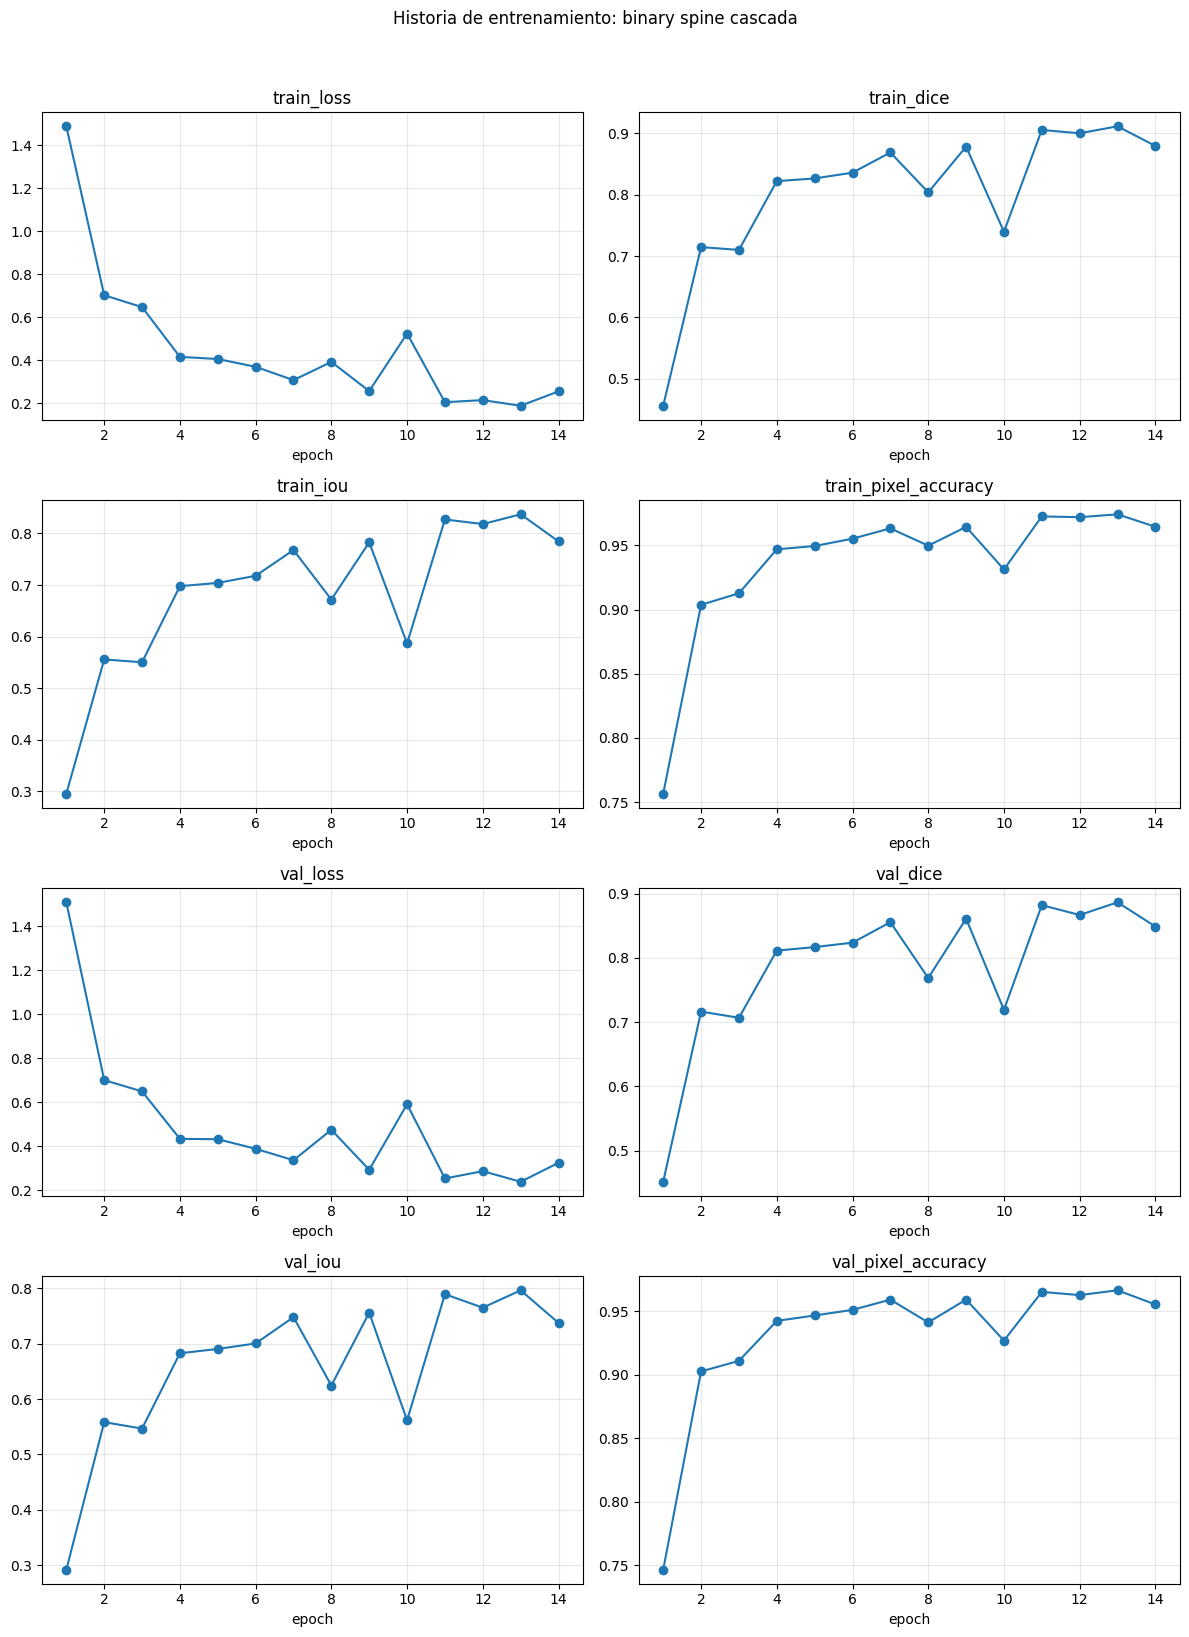

In [7]:
binary_train_ds = BinarySpineDataset(binary_splits_df.query("partition == 'train'"), image_size=IMG_SIZE_BINARY)
binary_val_ds = BinarySpineDataset(binary_splits_df.query("partition == 'val'"), image_size=IMG_SIZE_BINARY)
binary_test_ds = BinarySpineDataset(binary_splits_df.query("partition == 'test'"), image_size=IMG_SIZE_BINARY)

binary_train_loader = DataLoader(binary_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
binary_val_loader = DataLoader(binary_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
binary_test_loader = DataLoader(binary_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

binary_model = UNetSmall(in_channels=1, out_channels=1).to(DEVICE)
binary_optimizer = torch.optim.AdamW(binary_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
binary_bce = nn.BCEWithLogitsLoss()

binary_history = []
best_binary_state = None
best_binary_val_dice = -1.0
binary_start = time.time()

for epoch in range(1, BINARY_EPOCHS + 1):
    binary_model.train()
    running_loss = 0.0
    for batch in binary_train_loader:
        images = batch['image'].to(DEVICE)
        targets = batch['mask'].to(DEVICE)

        binary_optimizer.zero_grad()
        logits = binary_model(images)
        loss = binary_bce(logits, targets) + dice_loss_binary(logits, targets)
        loss.backward()
        binary_optimizer.step()
        running_loss += float(loss.item())

    train_metrics = evaluate_binary(binary_model, binary_train_loader)
    val_metrics = evaluate_binary(binary_model, binary_val_loader)
    row = {
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'train_dice': train_metrics['dice'],
        'train_iou': train_metrics['iou'],
        'train_pixel_accuracy': train_metrics['pixel_accuracy'],
        'val_loss': val_metrics['loss'],
        'val_dice': val_metrics['dice'],
        'val_iou': val_metrics['iou'],
        'val_pixel_accuracy': val_metrics['pixel_accuracy'],
    }
    binary_history.append(row)

    if val_metrics['dice'] > best_binary_val_dice:
        best_binary_val_dice = val_metrics['dice']
        best_binary_state = {k: v.detach().cpu().clone() for k, v in binary_model.state_dict().items()}

    print(
        f"[Binary][Epoch {epoch:02d}/{BINARY_EPOCHS}] "
        f"train_dice={row['train_dice']:.4f} "
        f"val_dice={row['val_dice']:.4f} "
        f"train_iou={row['train_iou']:.4f} "
        f"val_iou={row['val_iou']:.4f}"
    )

binary_history_df = pd.DataFrame(binary_history)
binary_model.load_state_dict(best_binary_state)
binary_test_metrics = evaluate_binary(binary_model, binary_test_loader)
binary_elapsed_min = (time.time() - binary_start) / 60.0

binary_model_path = MODEL_DIR / 'binary_spine_cascade_fase5_multiseed_s1337_best.pt'
binary_history_path = OUTPUT_DIR / 'binary_spine_history.csv'
binary_test_metrics_path = OUTPUT_DIR / 'binary_spine_test_metrics.csv'
torch.save(binary_model.state_dict(), binary_model_path)
binary_history_df.to_csv(binary_history_path, index=False)
pd.DataFrame([binary_test_metrics]).to_csv(binary_test_metrics_path, index=False)

print('\nMejor val_dice binario:', round(best_binary_val_dice, 4))
print('Metricas finales en test:', binary_test_metrics)
print('Tiempo de entrenamiento binario (min):', round(binary_elapsed_min, 2))

display(binary_history_df)
display(pd.DataFrame([binary_test_metrics]))
plot_history(binary_history_df, 'Historia de entrenamiento: binary spine cascada')

## Seccion 5. Construccion de la ROI predicha por el modelo binario

Despues de entrenar la red binaria, la usamos para estimar una caja de recorte (`ROI`) en las muestras multiclase.

Esta tabla de ROI es un puente entre la etapa 1 y la etapa 2:

- en `train` multiclase seguiremos usando ROI real para estabilidad
- en `val/test` multiclase usaremos ROI predicha para evaluar la cascada completa

In [8]:
def predict_binary_rois_for_table(
    model: nn.Module,
    table: pd.DataFrame,
    input_size: tuple[int, int],
    threshold: float = 0.50,
) -> pd.DataFrame:
    records = []
    model.eval()
    with torch.no_grad():
        for _, row in table.reset_index(drop=True).iterrows():
            image_raw = read_gray(row['radiograph_path_abs'])
            original_shape = image_raw.shape
            image_resized = resize_image(image_raw, input_size).astype(np.float32) / 255.0
            image_resized = torch.tensor(image_resized[None, None, ...], dtype=torch.float32, device=DEVICE)

            logits = model(image_resized)
            pred_mask_small = (torch.sigmoid(logits)[0, 0].detach().cpu().numpy() >= threshold).astype(np.uint8)
            bbox_small = bbox_from_mask(pred_mask_small, min_foreground_pixels=MIN_FOREGROUND_PIXELS)

            if bbox_small is None:
                roi_meta = build_roi_record_from_binary_mask(
                    np.zeros(original_shape, dtype=np.uint8),
                    image_shape=original_shape,
                    roi_source='pred_binary_empty',
                )
            else:
                bbox_original = scale_bbox(bbox_small, src_shape=input_size, dst_shape=original_shape)
                bbox_original = expand_bbox(bbox_original, image_shape=original_shape, pad_x=ROI_PAD_X, pad_y=ROI_PAD_Y)
                x0, y0, x1, y1 = bbox_original
                roi_meta = {
                    'bbox_x0': x0,
                    'bbox_y0': y0,
                    'bbox_x1': x1,
                    'bbox_y1': y1,
                    'bbox_width': x1 - x0,
                    'bbox_height': y1 - y0,
                    'roi_source': 'pred_binary',
                }

            records.append({'unique_sample_id': row['unique_sample_id'], **roi_meta})

    return pd.DataFrame(records)


multiclass_roi_df = predict_binary_rois_for_table(
    model=binary_model,
    table=multiclass_splits_df,
    input_size=IMG_SIZE_BINARY,
    threshold=BINARY_THRESHOLD,
)
multiclass_roi_path = OUTPUT_DIR / f'thoracolumbar_{MULTICLASS_SUBSET}_binary_rois.csv'
multiclass_roi_df.to_csv(multiclass_roi_path, index=False)
roi_lookup = multiclass_roi_df.set_index('unique_sample_id').to_dict(orient='index')

display(multiclass_roi_df.head())
display(multiclass_roi_df['roi_source'].value_counts().rename_axis('roi_source').reset_index(name='images'))
print('Tabla de ROI guardada en:', multiclass_roi_path)

,unique_sample_id,bbox_x0,bbox_y0,bbox_x1,bbox_y1,bbox_width,bbox_height,roi_source
0,Normal__N_1.jpg,61,0,204,916,143,916,pred_binary
1,Normal__N_2.jpg,39,0,183,759,144,759,pred_binary
2,Normal__N_5.jpg,25,0,140,571,115,571,pred_binary
3,Normal__N_7.jpg,36,0,176,875,140,875,pred_binary
4,Normal__N_8.jpg,54,37,152,627,98,590,pred_binary


,roi_source,images
0,pred_binary,198


Tabla de ROI guardada en: /content/drive/Othercomputers/Mi portátil/ScoliosisSegmentation/outputs/analysis_outputs_v3/training_runs_cascade_v3_fase5_multiseed_cuda_s1337/thoracolumbar_core_binary_rois.csv


## Seccion 6. Entrenamiento multiclase sobre ROI espinal

Aqui aparece la mejora principal respecto al notebook anterior.

Antes:

- la red multiclase veia la radiografia completa

Ahora:

- la red multiclase ve una region centrada en la columna

Beneficios esperados:

- menos distraccion por fondo
- mejor uso de la resolucion efectiva
- una tarea mas cercana a "identificar vertebras" que a "buscar columna y clasificar al mismo tiempo"

Tambien usamos:

- `CrossEntropy` ponderada por frecuencia de clase
- `Dice loss` multiclase
- seleccion del mejor checkpoint por `val_macro_dice_fg`

/tmp/ipykernel_1904/4041720878.py:147: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img_p = Image.fromarray(image_crop_u8, mode="L")
/tmp/ipykernel_1904/4041720878.py:149: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  msk_p = Image.fromarray(msk_u8, mode="L")
/tmp/ipykernel_1904/4041720878.py:169: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  ri = Image.fromarray(out_i, mode="L")
/tmp/ipykernel_1904/4041720878.py:170: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  rm = Image.fromarray(out_m.astype(np.uint8), mode="L")


[Cascade-Multiclass][Epoch 01/24] train_macro_dice=0.0148 val_macro_dice=0.0147 train_macro_iou=0.0076 val_macro_iou=0.0075
[Cascade-Multiclass][Epoch 02/24] train_macro_dice=0.0237 val_macro_dice=0.0229 train_macro_iou=0.0125 val_macro_iou=0.0120
[Cascade-Multiclass][Epoch 03/24] train_macro_dice=0.0549 val_macro_dice=0.0527 train_macro_iou=0.0293 val_macro_iou=0.0281
[Cascade-Multiclass][Epoch 04/24] train_macro_dice=0.0474 val_macro_dice=0.0477 train_macro_iou=0.0252 val_macro_iou=0.0252
[Cascade-Multiclass][Epoch 05/24] train_macro_dice=0.0835 val_macro_dice=0.0759 train_macro_iou=0.0460 val_macro_iou=0.0410
[Cascade-Multiclass][Epoch 06/24] train_macro_dice=0.0857 val_macro_dice=0.0939 train_macro_iou=0.0465 val_macro_iou=0.0513
[Cascade-Multiclass][Epoch 07/24] train_macro_dice=0.1136 val_macro_dice=0.1231 train_macro_iou=0.0630 val_macro_iou=0.0687
[Cascade-Multiclass][Epoch 08/24] train_macro_dice=0.1564 val_macro_dice=0.1630 train_macro_iou=0.0893 val_macro_iou=0.0922
[Cascade

,class_id,class_name,pixel_count,weight
0,0,background,12481644.0,0.250000
1,1,T1,152347.0,1.595917
2,2,T2,245021.0,0.992295
3,3,T3,215255.0,1.129513
4,4,T4,208332.0,1.167047
5,5,T5,220518.0,1.102555
6,6,T6,226377.0,1.074019
7,7,T7,244446.0,0.994630
8,8,T8,263728.0,0.921909
9,9,T9,277818.0,0.875153


,epoch,train_loss,train_pixel_accuracy,train_macro_dice_fg,train_macro_iou_fg,val_loss,val_pixel_accuracy,val_macro_dice_fg,val_macro_iou_fg
0,1,4.241604,0.162204,0.014845,0.007607,4.196040,0.178266,0.014660,0.007510
1,2,3.243351,0.660912,0.023727,0.012550,3.225058,0.674535,0.022859,0.011995
2,3,3.041061,0.670504,0.054901,0.029257,3.016791,0.671335,0.052745,0.028059
3,4,3.031061,0.667292,0.047442,0.025204,3.013600,0.651300,0.047748,0.025176
4,5,2.850330,0.684690,0.083548,0.046026,2.830007,0.683884,0.075864,0.040961
5,6,2.866817,0.664877,0.085739,0.046463,2.809607,0.674857,0.093883,0.051316
6,7,2.652110,0.679903,0.113574,0.062994,2.613824,0.680252,0.123132,0.068655
7,8,2.491830,0.701658,0.156399,0.089282,2.495869,0.694510,0.163030,0.092152
8,9,2.469871,0.697601,0.183056,0.106927,2.475113,0.698494,0.198231,0.115203
9,10,2.363017,0.723510,0.196998,0.115305,2.380262,0.716016,0.193259,0.111104


,loss,pixel_accuracy,macro_dice_fg,macro_iou_fg
0,2.1439,0.755699,0.245722,0.150346


,class_id,class_name,pred_pixels,target_pixels,dice,iou
0,0,background,3763747.0,3920169.0,0.938237,0.883660
2,2,T2,58103.0,63731.0,0.522399,0.353546
1,1,T1,76429.0,48287.0,0.515219,0.347000
16,16,L4,156647.0,89595.0,0.463487,0.301649
3,3,T3,96303.0,58434.0,0.426310,0.270899
17,17,L5,91924.0,70939.0,0.417811,0.264072
12,12,T12,136864.0,96254.0,0.285907,0.166798
4,4,T4,92157.0,59898.0,0.283726,0.165315
13,13,L1,116512.0,92926.0,0.260640,0.149848
8,8,T8,169627.0,86938.0,0.157800,0.085659


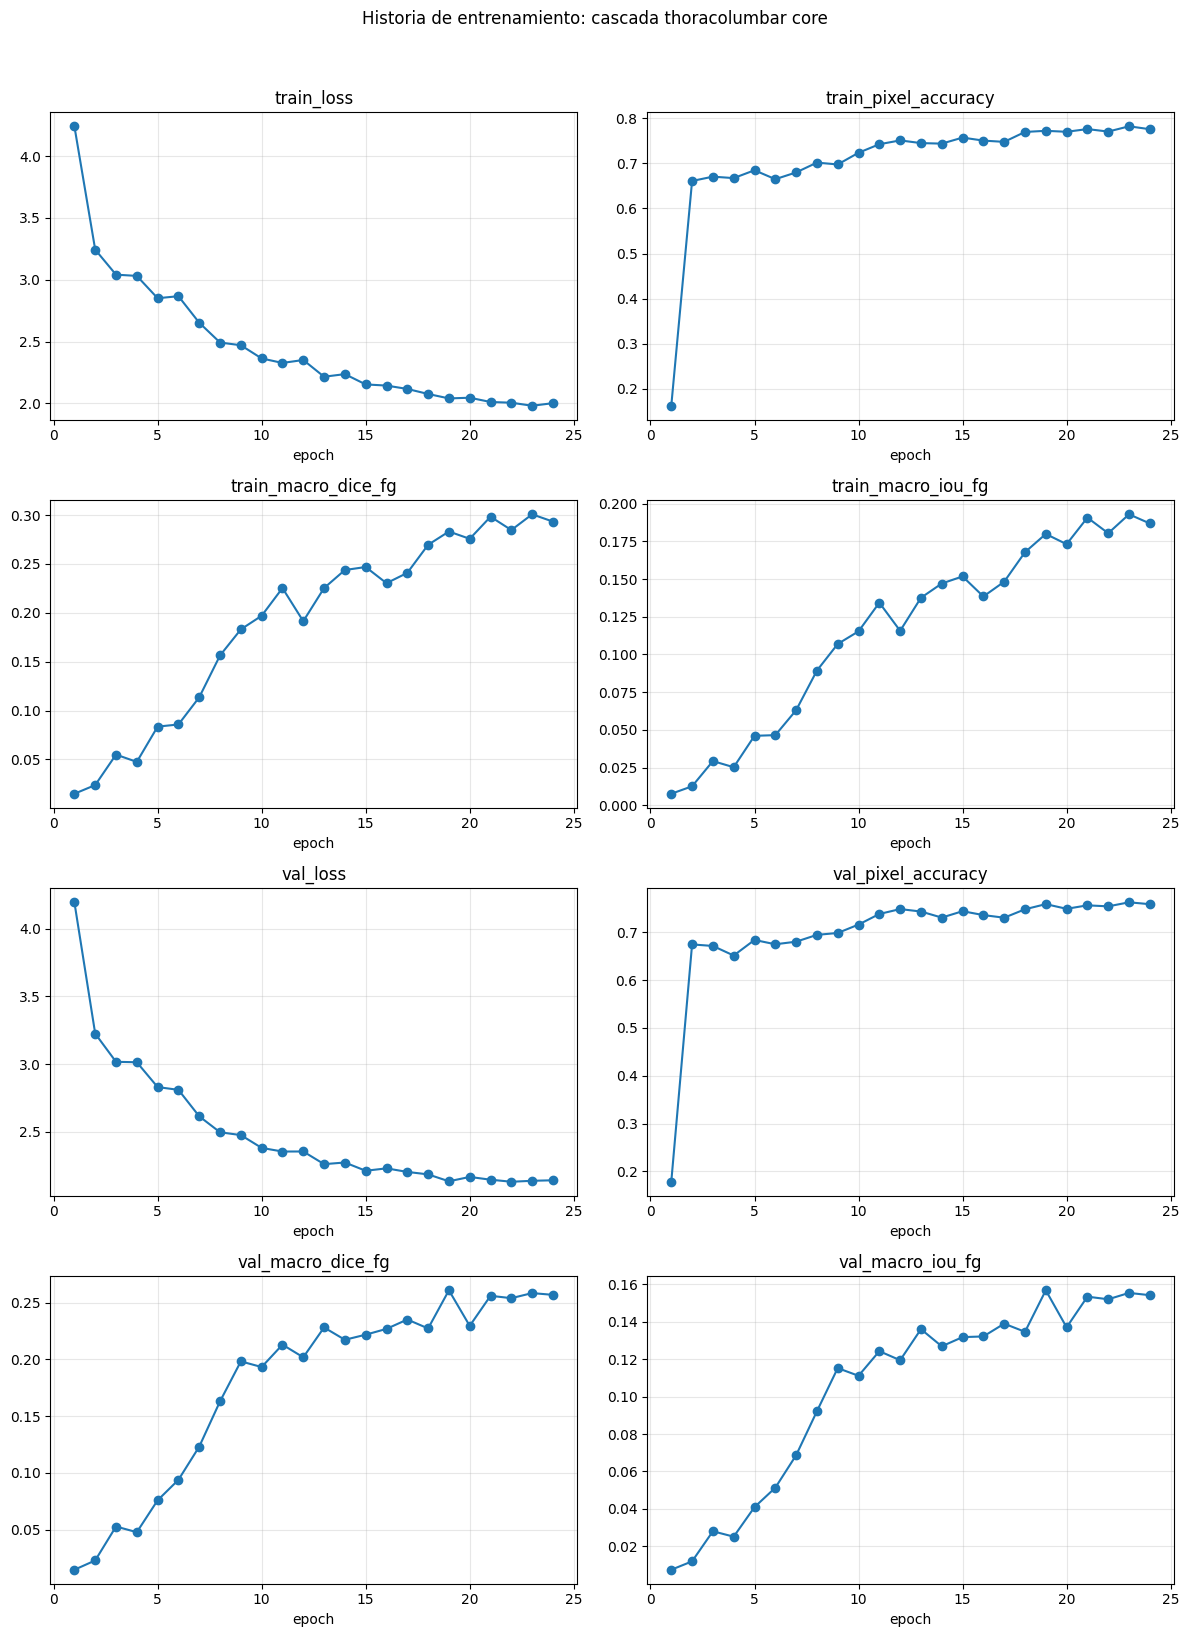

In [9]:
def estimate_multiclass_class_weights(table: pd.DataFrame) -> tuple[torch.Tensor, pd.DataFrame]:
    counts = np.ones(num_classes, dtype=np.float64)
    for _, row in table.reset_index(drop=True).iterrows():
        sample = prepare_multiclass_cascade_sample(
            row=row,
            output_size=IMG_SIZE_MULTICLASS,
            roi_mode='gt_binary',
            roi_lookup=None,
            apply_jitter=False,
        )
        mask = sample['mask']
        valid = mask != IGNORE_INDEX
        bincount = np.bincount(mask[valid].ravel(), minlength=num_classes)
        counts += bincount

    weights = counts.sum() / counts
    weights = weights / weights.mean()
    weights = np.clip(weights, 0.25, 8.0)
    weights_df = pd.DataFrame(
        {
            'class_id': np.arange(num_classes),
            'class_name': class_names,
            'pixel_count': counts,
            'weight': weights,
        }
    )
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE), weights_df


multiclass_train_ds = CascadedThoracolumbarDataset(
    multiclass_splits_df.query("partition == 'train'"),
    image_size=IMG_SIZE_MULTICLASS,
    roi_mode='gt_binary',
    roi_lookup=None,
    apply_jitter=True,
    apply_roi_augment=True,
)
multiclass_val_ds = CascadedThoracolumbarDataset(
    multiclass_splits_df.query("partition == 'val'"),
    image_size=IMG_SIZE_MULTICLASS,
    roi_mode='pred_binary',
    roi_lookup=roi_lookup,
    apply_jitter=False,
)
multiclass_test_ds = CascadedThoracolumbarDataset(
    multiclass_splits_df.query("partition == 'test'"),
    image_size=IMG_SIZE_MULTICLASS,
    roi_mode='pred_binary',
    roi_lookup=roi_lookup,
    apply_jitter=False,
)

multiclass_train_loader = DataLoader(multiclass_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
multiclass_val_loader = DataLoader(multiclass_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
multiclass_test_loader = DataLoader(multiclass_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

class_weights, class_weights_df = estimate_multiclass_class_weights(
    multiclass_splits_df.query("partition == 'train'")
)
multiclass_loss_fn = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_INDEX)
multiclass_model = UNetSmall(in_channels=1, out_channels=num_classes).to(DEVICE)
# --- [Fase 3 adoptada] LR multiclase ×0,5 + CosineAnnealingLR (solo etapa multiclase) ---
_MULTICLASS_LR_SCALE = 0.5
LR_MULTICLASS = LR * _MULTICLASS_LR_SCALE
multiclass_optimizer = torch.optim.AdamW(
    multiclass_model.parameters(), lr=LR_MULTICLASS, weight_decay=WEIGHT_DECAY
)
multiclass_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    multiclass_optimizer, T_max=MULTICLASS_EPOCHS, eta_min=max(float(1e-8), LR_MULTICLASS * 0.01)
)

multiclass_history = []
best_multiclass_state = None
best_multiclass_val_macro_dice = -1.0
multiclass_start = time.time()

for epoch in range(1, MULTICLASS_EPOCHS + 1):
    multiclass_model.train()
    for batch in multiclass_train_loader:
        images = batch['image'].to(DEVICE)
        targets = batch['mask'].to(DEVICE)

        multiclass_optimizer.zero_grad()
        logits = multiclass_model(images)
        loss = multiclass_loss_fn(logits, targets) + dice_loss_multiclass(
            logits, targets, num_classes=num_classes, ignore_index=IGNORE_INDEX
        )
        loss.backward()
        multiclass_optimizer.step()

    train_metrics, _ = evaluate_multiclass(multiclass_model, multiclass_train_loader, loss_fn=multiclass_loss_fn)
    val_metrics, _ = evaluate_multiclass(multiclass_model, multiclass_val_loader, loss_fn=multiclass_loss_fn)
    row = {
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'train_pixel_accuracy': train_metrics['pixel_accuracy'],
        'train_macro_dice_fg': train_metrics['macro_dice_fg'],
        'train_macro_iou_fg': train_metrics['macro_iou_fg'],
        'val_loss': val_metrics['loss'],
        'val_pixel_accuracy': val_metrics['pixel_accuracy'],
        'val_macro_dice_fg': val_metrics['macro_dice_fg'],
        'val_macro_iou_fg': val_metrics['macro_iou_fg'],
    }
    multiclass_history.append(row)

    if val_metrics['macro_dice_fg'] > best_multiclass_val_macro_dice:
        best_multiclass_val_macro_dice = val_metrics['macro_dice_fg']
        best_multiclass_state = {k: v.detach().cpu().clone() for k, v in multiclass_model.state_dict().items()}

    print(
        f"[Cascade-Multiclass][Epoch {epoch:02d}/{MULTICLASS_EPOCHS}] "
        f"train_macro_dice={row['train_macro_dice_fg']:.4f} "
        f"val_macro_dice={row['val_macro_dice_fg']:.4f} "
        f"train_macro_iou={row['train_macro_iou_fg']:.4f} "
        f"val_macro_iou={row['val_macro_iou_fg']:.4f}"
    )
    multiclass_scheduler.step()

multiclass_history_df = pd.DataFrame(multiclass_history)
multiclass_model.load_state_dict(best_multiclass_state)
multiclass_test_metrics, multiclass_per_class_df = evaluate_multiclass(
    multiclass_model,
    multiclass_test_loader,
    loss_fn=multiclass_loss_fn,
)
multiclass_elapsed_min = (time.time() - multiclass_start) / 60.0

multiclass_model_path = MODEL_DIR / f'thoracolumbar_{MULTICLASS_SUBSET}_cascade_fase5_multiseed_s1337_best.pt'
multiclass_history_path = OUTPUT_DIR / f'thoracolumbar_{MULTICLASS_SUBSET}_history.csv'
multiclass_test_metrics_path = OUTPUT_DIR / f'thoracolumbar_{MULTICLASS_SUBSET}_test_metrics.csv'
multiclass_per_class_path = OUTPUT_DIR / f'thoracolumbar_{MULTICLASS_SUBSET}_per_class_metrics.csv'
multiclass_class_weights_path = OUTPUT_DIR / f'thoracolumbar_{MULTICLASS_SUBSET}_class_weights.csv'

torch.save(multiclass_model.state_dict(), multiclass_model_path)
multiclass_history_df.to_csv(multiclass_history_path, index=False)
pd.DataFrame([multiclass_test_metrics]).to_csv(multiclass_test_metrics_path, index=False)
multiclass_per_class_df.to_csv(multiclass_per_class_path, index=False)
class_weights_df.to_csv(multiclass_class_weights_path, index=False)

print('\nMejor val_macro_dice_fg:', round(best_multiclass_val_macro_dice, 4))
print('Metricas finales en test:', multiclass_test_metrics)
print('Tiempo de entrenamiento multiclase (min):', round(multiclass_elapsed_min, 2))

display(class_weights_df)
display(multiclass_history_df)
display(pd.DataFrame([multiclass_test_metrics]))
display(multiclass_per_class_df.sort_values('dice', ascending=False))
plot_history(multiclass_history_df, f'Historia de entrenamiento: cascada thoracolumbar {MULTICLASS_SUBSET}')

## Seccion 7. Visualizacion cualitativa

Las metricas son necesarias, pero no suficientes.

En problemas de imagen medica siempre conviene revisar ejemplos visuales para responder preguntas como:

- la binaria recorta bien la columna?
- la ROI realmente enfoca la zona util?
- la multiclase esta confundiendo vertebras vecinas?
- el modelo sobre-segmenta o sub-segmenta?

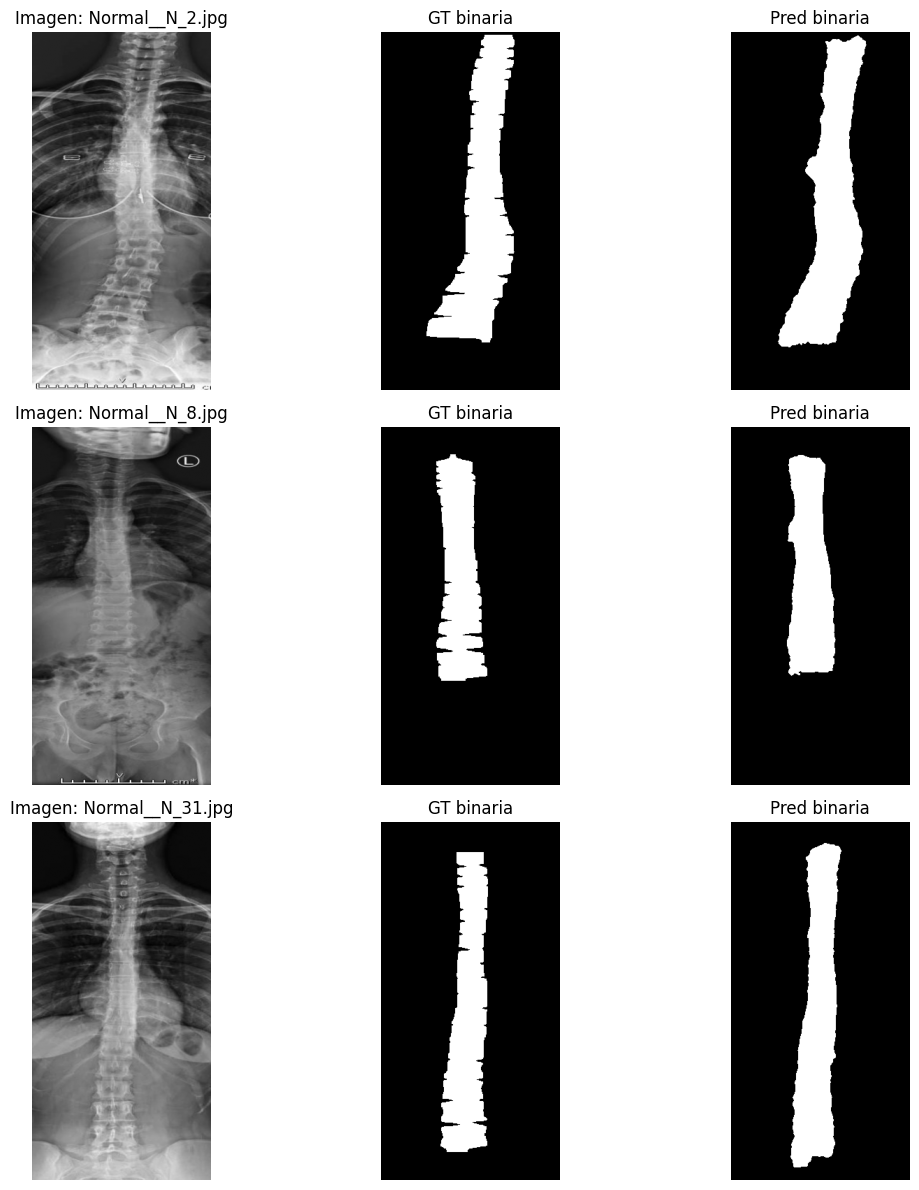

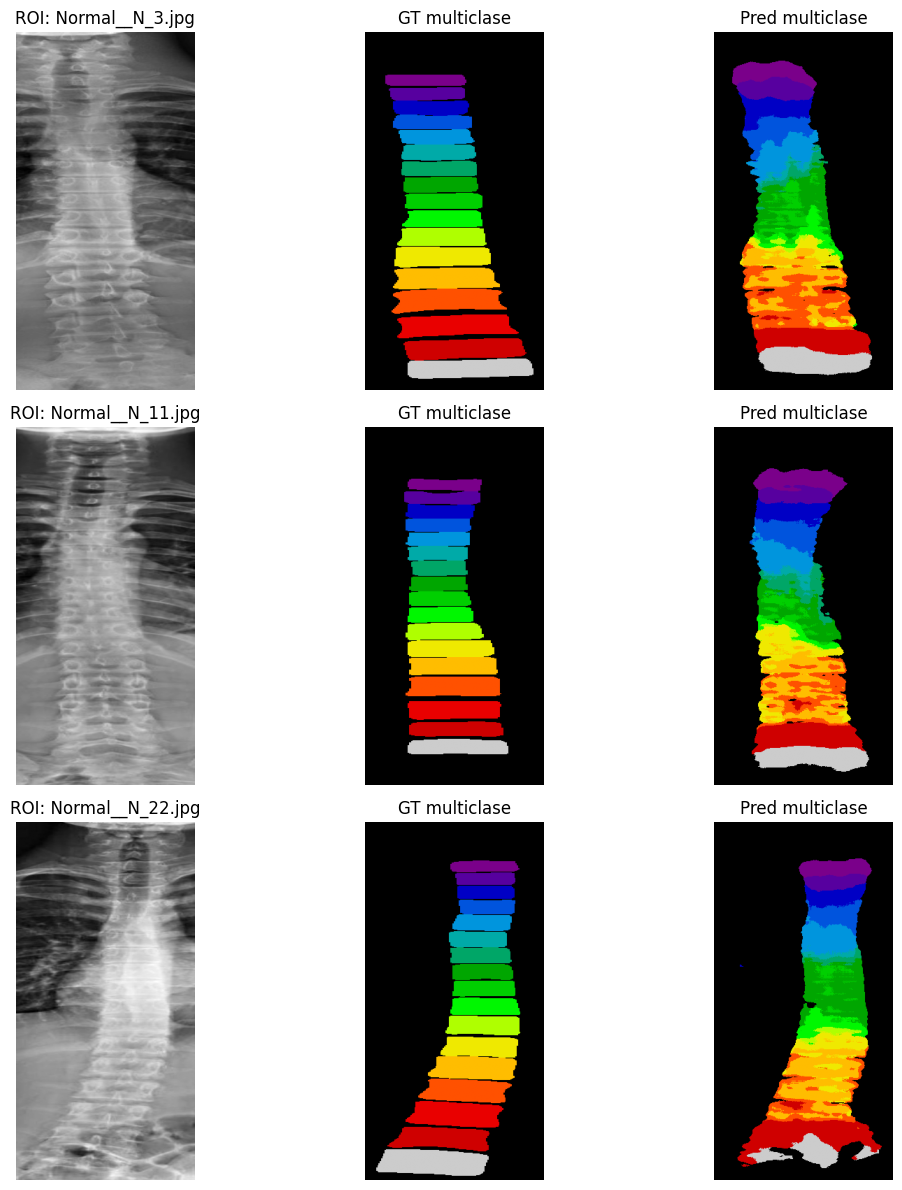

In [10]:
def show_binary_predictions(model: nn.Module, dataset: Dataset, n: int = 3) -> None:
    model.eval()
    n = min(n, len(dataset))
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    axes = np.atleast_2d(axes)
    with torch.no_grad():
        for idx in range(n):
            sample = dataset[idx]
            image = sample['image'].unsqueeze(0).to(DEVICE)
            target = sample['mask'][0].numpy()
            pred = (torch.sigmoid(model(image))[0, 0].detach().cpu().numpy() >= BINARY_THRESHOLD).astype(np.uint8)
            axes[idx, 0].imshow(sample['image'][0].numpy(), cmap='gray')
            axes[idx, 0].set_title(f"Imagen: {sample['sample_id']}")
            axes[idx, 1].imshow(target, cmap='gray')
            axes[idx, 1].set_title('GT binaria')
            axes[idx, 2].imshow(pred, cmap='gray')
            axes[idx, 2].set_title('Pred binaria')
            for j in range(3):
                axes[idx, j].axis('off')
    plt.tight_layout()
    plt.show()


def show_cascade_multiclass_predictions(model: nn.Module, dataset: Dataset, n: int = 3) -> None:
    model.eval()
    n = min(n, len(dataset))
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    axes = np.atleast_2d(axes)
    with torch.no_grad():
        for idx in range(n):
            sample = dataset[idx]
            image = sample['image'].unsqueeze(0).to(DEVICE)
            pred = torch.argmax(model(image), dim=1)[0].detach().cpu().numpy()
            target = sample['mask'].numpy().copy()
            target[target == IGNORE_INDEX] = 0
            axes[idx, 0].imshow(sample['image'][0].numpy(), cmap='gray')
            axes[idx, 0].set_title(f"ROI: {sample['sample_id']}")
            axes[idx, 1].imshow(target, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
            axes[idx, 1].set_title('GT multiclase')
            axes[idx, 2].imshow(pred, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
            axes[idx, 2].set_title('Pred multiclase')
            for j in range(3):
                axes[idx, j].axis('off')
    plt.tight_layout()
    plt.show()


show_binary_predictions(binary_model, binary_test_ds, n=3)
show_cascade_multiclass_predictions(multiclass_model, multiclass_test_ds, n=3)

## Como interpretar este notebook al terminar

Este notebook entrena primero una segmentación **binaria** (columna vs fondo) y luego una segmentación **multiclase** (vértebras) sobre el recorte definido por esa binaria. Al terminar, la pregunta práctica es: **¿la segunda etapa recibe una ROI útil y mejora el reconocimiento por vértebra frente al pipeline "plano" del notebook `train_spine_binary_and_thoracolumbar_v3`?**

Compara siempre contra los CSV del otro notebook en `analysis_outputs_v3/training_runs_v3/` y los de este run en `analysis_outputs_v3/training_runs_cascade_v3/`.

### Señales positivas

- **Binaria**: `Dice` e `IoU` de test altos y, en el histórico, curvas de validación razonablemente estables (sin colapso temprano).
- **ROI**: en `thoracolumbar_core_binary_rois.csv`, `roi_source` mayoritariamente `pred_binary` y **pocos o ningún** `fallback_full_image` (significa que la etapa 1 aporta caja útil para la etapa 2).
- **Multiclase (foreground)**: suben `val_macro_dice_fg` / `test_macro_dice_fg` y, en coherencia, suelen subir `macro_iou_fg` frente al run plano — son las métricas que importan para clases raras.
- **Balance torácico/lumbar**: en `thoracolumbar_core_per_class_metrics.csv` se reduce el "agujero" sistemático en vértebras finales o medias si antes había colapso (p. ej. L5 sin predicción).

### Señales de alerta (no confundir con fallo automático)

- **`pixel_accuracy` multiclase** puede **bajar** respecto al run sobre imagen completa porque el recorte tiene **menos fondo dominante**; eso **no invalida** la mejora si sube `macro_dice_fg`. No compares `pixel_accuracy` entre pipelines de forma ingenua.
- **`loss` multiclase** puede **subir** en cascada (distribución de píxeles más difícil / menos fondo "fácil"); guíate por Dice/IoU macro y por clase.
- **Macro alto con clases malas**: revisa siempre el **desglose por clase**; el macro puede ocultar regresiones fuertes en T9–T11 si otras suben mucho.
- **ROI vacía o enorme**, o muchos `fallback_full_image`: la etapa 2 estaría viendo datos degenerados.

### Qué archivos mirar primero

1. `binary_spine_test_metrics.csv` (ambos runs) — fuerza del detector de columna.
2. `thoracolumbar_core_test_metrics.csv` — resumen multiclase.
3. `thoracolumbar_core_per_class_metrics.csv` — dónde ganaste o perdiste por vértebra.
4. `thoracolumbar_core_binary_rois.csv` — calidad y origen del recorte.
5. `thoracolumbar_core_history.csv` — época con mejor `val_macro_dice_fg` y sobreajuste.

### Si el multiclase sigue flojo, mejoras naturales (orden sugerido)

1. Augmentación geométrica **suave** acorde a radiografías (rotaciones/pequeñas escalas), sin romper anatomía.
2. **Mayor resolución efectiva** del recorte multiclase o padding/letterbox consistente con el entrenamiento plano.
3. **Encoder preentrenado** (ImageNet o médico) si aún no se usa.
4. Entrenar después el esquema `partial` cuando `core` esté estable.
5. Post-proceso: restricción anatómica (orden, vecinos) o regresión de centroides por vértebra.



### Sugerencias para mejorar este notebook o el procedimiento

Justificación breve entre paréntesis.

1. **Inspección visual sistemática de ROI** (`thoracolumbar_core_binary_rois.csv` + overlays): detectar si T9–T11 quedan mal centradas o cortadas (justificación: regresión localizada suele venir de geometría del recorte, no solo del clasificador).

2. **Letterbox / padding fijo** del recorte multiclase a la resolución de entrenamiento del plano (justificación: evita escalas implícitas distintas entre etapas y reduce confusión entre niveles adyacentes).

3. **Pérdida o muestreo conscientes de clase** en el tramo T7–T12 (focal, pesos actualizados por frecuencia en ROI, o crop duro al centro dorsal en augmentación) (justificación: el macro sube pero T9–T11 se degrada; hay que proteger clases "intermedias").

4. **Congelar o bajar LR** en la etapa multiclase tras estabilizar binaria, o **scheduler** más conservador (justificación: menos riesgo de sobreajuste a patrones de borde dentro del ROI).

5. **Validación cruzada o repetición con semillas** si el test es pequeño (justificación: robustez de la conclusión "cascada > plano" ante variabilidad de split).

6. **Post-proceso ligero**: suavizado de máscaras por nivel o restricción de que las etiquetas aparezcan en orden vertical esperado (justificación: información anatómica barata que reduce confusiones T9↔T10 sin reentrenar).

7. **Documentar en el notebook** el criterio exacto de split (mismo `unique_sample_id` que el plano o no) (justificación: comparaciones justas entre notebooks).



> **Fase 5 (multiseed `_cuda`):** lectura del **run de esta variante** frente al **baseline cascada**, al **Fase 4 `_cuda`** (`training_runs_cascade_v3_fase4_augment_roi_cuda/`), a las **otras semillas** de esta misma fase y a la carpeta `OUTPUT_DIR` de este notebook.


### Análisis e interpretación

#### Tabla comparativa — tres semillas Fase 5 (test)

| Semilla | `macro_dice_fg` | `macro_iou_fg` | Bin Dice | Bin IoU | Mejor `val_macro_dice_fg` (época) |
|---------|-----------------|----------------|----------|---------|-----------------------------------|
| 42 | 0,2294 | 0,1365 | 0,8710 | 0,7714 | 0,2226 (ép. 22) |
| 1337 | 0,2457 | 0,1503 | 0,8943 | 0,8088 | 0,2609 (ép. 19) |
| 4242 | 0,1737 | 0,1035 | 0,8582 | 0,7516 | 0,1685 (ép. 24) |

**Referencias:** baseline `macro_dice_fg` **0,1894** (`training_runs_cascade_v3/`); Fase 4 `_cuda` **0,2380** (`training_runs_cascade_v3_fase4_augment_roi_cuda/`).

#### Dice por clase (test): T9, T10, T11, L5

| Semilla | T9 | T10 | T11 | L5 |
|---------|-----|------|------|-----|
| 42 | 0,0935 | 0,0831 | 0,1977 | 0,1807 |
| 1337 | 0,1480 | 0,1261 | 0,0800 | 0,4178 |
| 4242 | 0,1283 | **0,0000** | 0,1653 | 0,3326 |

**ROI:** en los tres runs, `thoracolumbar_core_binary_rois.csv` contiene **198** filas con `roi_source=pred_binary`.

#### Lectura frente al plan (§3 Fase 5)

- **Replicación:** no estable entre semillas: **1337** supera a Fase 4 en macro FG (**+0,0077**); **42** queda por debajo (**−0,0086** vs 0,2380); **4242** cae por debajo del baseline en macro y exhibe **T10 con Dice 0** en test.
- **Binario:** 1337 mejora frente al baseline; 42 se alinea con el baseline histórico; 4242 muestra ligera baja de Dice.
- **Decisión de fase:** **«Prometedor; no consolidado»** — no se añade un cambio de código al vivo (ya integra Fase 3 + Fase 4); se documenta **alta varianza** del macro multiclase ante la semilla bajo el mismo split y augment.

**Esta variante (`SEED=1337`):** mejor macro FG de la tanda (**0,2457**); el binario también sube (Dice **0,8943**). Sirve como evidencia de que **existen** semillas favorables, pero no bastan sin replicación estable.


### Sugerencias posteriores

1. **Fase 6** (`train_spine_cascade_binary_to_thoracolumbar_v3_mejorafase6_postproceso_ligero/`): **cerrada** — post islas (`K=0`) **no** mejoró `macro_dice_fg` en test; decisión **No adoptar** (ver `RESULTADOS_Y_DECISIONES_GENERAL.md`). **Fase 7:** estimador `last_visible` / clipping — `notebooks/07_colab_train_last_visible_estimator_and_clip_thoracolumbar_explained.ipynb` y carpeta `…_mejorafase7_auxiliares_rango_lastvis/`.
2. Opcional: ampliar a **más semillas** o reportar media ± desviación estándar sobre ≥5 runs para informes finales.
3. Tras cada run, confirmar que existan `thoracolumbar_core_test_metrics.csv` y el bloque de **Registro de ejecución** al pie del notebook.


## Registro de ejecución del notebook

La **fecha de última modificación** del archivo `.ipynb` en disco **no** indica cuándo terminó el entrenamiento: cambia en cada guardado.

**Recomendación:** al finalizar entrenamiento y evaluación, ejecutar la **celda de código siguiente** (la salida queda guardada en el notebook y marca el momento de esa ejecución). Opcionalmente completar la tabla.

| Campo | Valor |
|-------|--------|
| **Fecha de cierre del run** | *(ver salida de la celda siguiente o anotar)* |
| **Entorno** | *(p. ej. Colab T4, VS Code + CUDA, …)* |


In [11]:
# --- Registro de ejecución: ejecutar al finalizar entrenamiento y evaluación ---
from __future__ import annotations

from datetime import datetime, timezone

now_local = datetime.now().astimezone()
now_utc = datetime.now(timezone.utc)
print("Ejecución de esta celda — local:", now_local.strftime("%Y-%m-%d %H:%M:%S %Z"))
print("Ejecución de esta celda — UTC:  ", now_utc.strftime("%Y-%m-%d %H:%M:%S UTC"))


Ejecución de esta celda — local: 2026-05-15 04:44:07 UTC
Ejecución de esta celda — UTC:   2026-05-15 04:44:07 UTC
